In [1]:
#Import libraries, load the dataset, and convert it into a DataFrame.

import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Initial exploration of the dataset structure, shape, and missing values before any cleaning. 
# Lines commented out below were used for inspection and are kept for reference.

#df.head()
#df.tail()
#df.shape
#df.describe()
#df.info()
#df.isnull().sum()

# Data cleanup:
# - Convert job_posted_date from string to datetime.
# - Convert job_skills from a string representation of a list into an 
# actual Python list using ast.literal_eval, skipping NaN values.

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

In [ ]:
# Question: What are the most optimal skills to learn for Data Analysts in the US 
# (balancing high demand percentage and high median salary)?

df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US = df_DA_US.dropna(subset='salary_year_avg')
df_DA_US_explode = df_DA_US.explode('job_skills')

df_DA_skills = df_DA_US_explode.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})
df_DA_total = len(df_DA_US)

df_DA_skills['skill_percent'] = (df_DA_skills['skill_count'] / df_DA_total) * 100
skill_limit = 5
df_DA_skills_high_demand = df_DA_skills[(df_DA_skills['skill_percent']) > skill_limit]

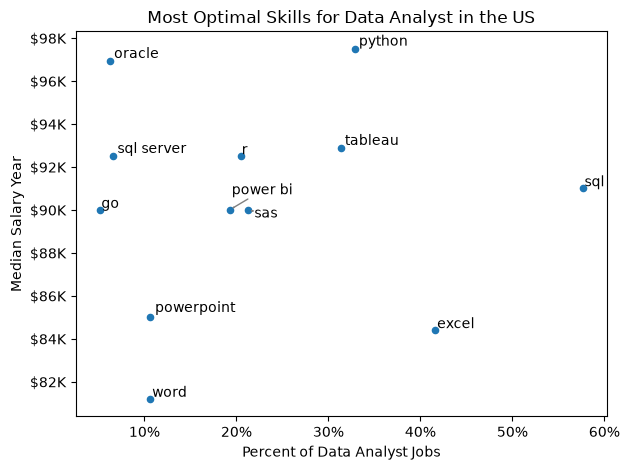

In [64]:
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter

df_DA_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')

texts = []

for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.title('Most Optimal Skills for Data Analyst in the US')
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary Year')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.tight_layout()
plt.show()